In [1]:
import sys
print(sys.executable)   # should show a path containing .../envs/py311/...

import pandas as pd
print(pd.__version__)   # should just print a version number, no error

/opt/anaconda3/envs/py311/bin/python
3.0.5


In [2]:
import pandas as pd
import os

raw_dir = '../data/raw'
files = [f for f in os.listdir(raw_dir) if f.endswith('.xlsx')]
print("Found files:", files)

for f in files:
    if f.startswith('~$'):
        continue
    print('\n===', f, '===')
    df = pd.read_excel(os.path.join(raw_dir, f))
    print('shape:', df.shape)
    print('columns:', df.columns.tolist())
    print(df.head(3))

Found files: ['Subnational 1 tree cover loss.xlsx', 'Subnational 1 carbon data.xlsx', 'Country tree cover loss.xlsx', 'Subnational 2 carbon data.xlsx', '~$Country tree cover loss.xlsx', 'Country carbon data.xlsx', 'Subnational 2 tree cover loss.xlsx']

=== Subnational 1 tree cover loss.xlsx ===
shape: (288, 27)
columns: ['country', 'subnational1', 'threshold', 'area_ha', 'extent_2000_ha', 'extent_2010_ha', 'gain_2000-2012_ha', 'tc_loss_ha_2001', 'tc_loss_ha_2002', 'tc_loss_ha_2003', 'tc_loss_ha_2004', 'tc_loss_ha_2005', 'tc_loss_ha_2006', 'tc_loss_ha_2007', 'tc_loss_ha_2008', 'tc_loss_ha_2009', 'tc_loss_ha_2010', 'tc_loss_ha_2011', 'tc_loss_ha_2012', 'tc_loss_ha_2013', 'tc_loss_ha_2014', 'tc_loss_ha_2015', 'tc_loss_ha_2016', 'tc_loss_ha_2017', 'tc_loss_ha_2018', 'tc_loss_ha_2019', 'tc_loss_ha_2020']
  country         subnational1  threshold  area_ha  extent_2000_ha  \
0   India  Andaman and Nicobar          0   761084          761084   
1   India  Andaman and Nicobar         10   76108

In [6]:
# ==========================================
# CLEANING AND RESHAPING DATASETS
# ==========================================
import pandas as pd

# ------------------------------------------
# 1. SUBNATIONAL 1 DATASET
# ------------------------------------------
df1 = pd.read_excel('../data/raw/Subnational 1 tree cover loss.xlsx')

# Standardize on the 30% canopy-cover threshold
df1_30 = df1[df1['threshold'] == 30].copy()
loss_cols1 = [c for c in df1.columns if c.startswith('tc_loss_ha_')]

long_df1 = df1_30.melt(
    id_vars=['country', 'subnational1', 'extent_2000_ha', 'extent_2010_ha', 'gain_2000-2012_ha'],
    value_vars=loss_cols1,
    var_name='year',
    value_name='tc_loss_ha'
)

long_df1['year'] = long_df1['year'].str.replace('tc_loss_ha_', '').astype(int)
long_df1['loss_pct'] = long_df1['tc_loss_ha'] / long_df1['extent_2000_ha'] * 100
long_df1 = long_df1.sort_values(['subnational1', 'year']).reset_index(drop=True)

# Inspect Subnational 1
print("--- Subnational 1 Results ---")
print("Shape:", long_df1.shape)
print("Unique states:", long_df1['subnational1'].nunique())
print("State list:", sorted(long_df1['subnational1'].unique().tolist()))


# ------------------------------------------
# 2. SUBNATIONAL 2 DATASET
# ------------------------------------------
df2 = pd.read_excel('../data/raw/Subnational 2 tree cover loss.xlsx')

# Standardize on the 30% canopy-cover threshold
df2_30 = df2[df2['threshold'] == 30].copy()
loss_cols2 = [c for c in df2.columns if c.startswith('tc_loss_ha_')]

# Check if 'subnational2' exists before melting to avoid errors
sub2_col = 'subnational2' if 'subnational2' in df2.columns else df2.columns[1]

long_df2 = df2_30.melt(
    id_vars=['country', 'subnational1', sub2_col, 'extent_2000_ha', 'extent_2010_ha', 'gain_2000-2012_ha'],
    value_vars=loss_cols2,
    var_name='year',
    value_name='tc_loss_ha'
)

long_df2['year'] = long_df2['year'].str.replace('tc_loss_ha_', '').astype(int)
long_df2['loss_pct'] = long_df2['tc_loss_ha'] / long_df2['extent_2000_ha'] * 100
long_df2 = long_df2.sort_values([sub2_col, 'year']).reset_index(drop=True)

# Inspect Subnational 2
print("\n--- Subnational 2 Results ---")
print("Shape:", long_df2.shape)
print("Unique sub-units:", long_df2[sub2_col].nunique())
print("Sub-unit list:", sorted(long_df2[sub2_col].unique().tolist()))# ==========================================
# CLEANING AND RESHAPING DATASETS
# ==========================================
import pandas as pd

# ------------------------------------------
# 1. SUBNATIONAL 1 DATASET
# ------------------------------------------
df1 = pd.read_excel('../data/raw/Subnational 1 tree cover loss.xlsx')

# Standardize on the 30% canopy-cover threshold
df1_30 = df1[df1['threshold'] == 30].copy()
loss_cols1 = [c for c in df1.columns if c.startswith('tc_loss_ha_')]

long_df1 = df1_30.melt(
    id_vars=['country', 'subnational1', 'extent_2000_ha', 'extent_2010_ha', 'gain_2000-2012_ha'],
    value_vars=loss_cols1,
    var_name='year',
    value_name='tc_loss_ha'
)

long_df1['year'] = long_df1['year'].str.replace('tc_loss_ha_', '').astype(int)
long_df1['loss_pct'] = long_df1['tc_loss_ha'] / long_df1['extent_2000_ha'] * 100
long_df1 = long_df1.sort_values(['subnational1', 'year']).reset_index(drop=True)

# Inspect Subnational 1
print("--- Subnational 1 Results ---")
print("Shape:", long_df1.shape)
print("Unique states:", long_df1['subnational1'].nunique())
print("State list:", sorted(long_df1['subnational1'].unique().tolist()))


# ------------------------------------------
# 2. SUBNATIONAL 2 DATASET
# ------------------------------------------
df2 = pd.read_excel('../data/raw/Subnational 2 tree cover loss.xlsx')

# Standardize on the 30% canopy-cover threshold
df2_30 = df2[df2['threshold'] == 30].copy()
loss_cols2 = [c for c in df2.columns if c.startswith('tc_loss_ha_')]

# Check if 'subnational2' exists before melting to avoid errors
sub2_col = 'subnational2' if 'subnational2' in df2.columns else df2.columns[1]

long_df2 = df2_30.melt(
    id_vars=['country', sub2_col, 'extent_2000_ha', 'extent_2010_ha', 'gain_2000-2012_ha'],
    value_vars=loss_cols2,
    var_name='year',
    value_name='tc_loss_ha'
)

long_df2['year'] = long_df2['year'].str.replace('tc_loss_ha_', '').astype(int)
long_df2['loss_pct'] = long_df2['tc_loss_ha'] / long_df2['extent_2000_ha'] * 100
long_df2 = long_df2.sort_values([sub2_col, 'year']).reset_index(drop=True)

# Inspect Subnational 2
print("\n--- Subnational 2 Results ---")
print("Shape:", long_df2.shape)
print("Unique sub-units:", long_df2[sub2_col].nunique())
print("Sub-unit list:", sorted(long_df2[sub2_col].unique().tolist()))

--- Subnational 1 Results ---
Shape: (720, 8)
Unique states: 36
State list: ['Andaman and Nicobar', 'Andhra Pradesh', 'Arunachal Pradesh', 'Assam', 'Bihar', 'Chandigarh', 'Chhattisgarh', 'Dadra and Nagar Haveli', 'Daman and Diu', 'Goa', 'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jammu and Kashmir', 'Jharkhand', 'Karnataka', 'Kerala', 'Lakshadweep', 'Madhya Pradesh', 'Maharashtra', 'Manipur', 'Meghalaya', 'Mizoram', 'NCT of Delhi', 'Nagaland', 'Odisha', 'Puducherry', 'Punjab', 'Rajasthan', 'Sikkim', 'Tamil Nadu', 'Telangana', 'Tripura', 'Uttar Pradesh', 'Uttarakhand', 'West Bengal']

--- Subnational 2 Results ---
Shape: (13320, 9)
Unique sub-units: 659
Sub-unit list: ['Adilabad', 'Agar Malwa', 'Agra', 'Ahmadabad', 'Ahmadnagar', 'Aizawl', 'Ajmer', 'Akola', 'Alappuzha', 'Aligarh', 'Alipurduar', 'Alirajpur', 'Allahabad', 'Almora', 'Alwar', 'Ambala', 'Ambedkar Nagar', 'Amethi', 'Amravati', 'Amreli', 'Amritsar', 'Amroha', 'Anand', 'Anantapur', 'Anantnag', 'Anjaw', 'Anugul', 'Anuppur', 'Arari

In [7]:
long_df1['loss_pct_lag1'] = long_df1.groupby('subnational1')['loss_pct'].shift(1)
long_df1['loss_pct_lag2'] = long_df1.groupby('subnational1')['loss_pct'].shift(2)
long_df1['loss_pct_roll3'] = (
    long_df1.groupby('subnational1')['loss_pct']
    .transform(lambda x: x.shift(1).rolling(3).mean())
)
long_df1['target_loss_pct_next_year'] = long_df1.groupby('subnational1')['loss_pct'].shift(-1)

model_df = long_df1.dropna(
    subset=['loss_pct_lag1', 'loss_pct_lag2', 'loss_pct_roll3', 'target_loss_pct_next_year']
).copy()

print(model_df.shape)
model_df.head(10)

(560, 12)


,country,subnational1,extent_2000_ha,extent_2010_ha,gain_2000-2012_ha,year,tc_loss_ha,loss_pct,loss_pct_lag1,loss_pct_lag2,loss_pct_roll3,target_loss_pct_next_year
3,India,Andaman and Nicobar,684402,679440,5845,2004,211,0.030830,0.238310,0.275569,0.239966,0.517094
4,India,Andaman and Nicobar,684402,679440,5845,2005,3539,0.517094,0.030830,0.238310,0.181570,0.119520
5,India,Andaman and Nicobar,684402,679440,5845,2006,818,0.119520,0.517094,0.030830,0.262078,0.116014
6,India,Andaman and Nicobar,684402,679440,5845,2007,794,0.116014,0.119520,0.517094,0.222481,0.253944
7,India,Andaman and Nicobar,684402,679440,5845,2008,1738,0.253944,0.116014,0.119520,0.250876,0.122443
8,India,Andaman and Nicobar,684402,679440,5845,2009,838,0.122443,0.253944,0.116014,0.163159,0.113238
9,India,Andaman and Nicobar,684402,679440,5845,2010,775,0.113238,0.122443,0.253944,0.164134,0.014319
10,India,Andaman and Nicobar,684402,679440,5845,2011,98,0.014319,0.113238,0.122443,0.163208,0.101110
11,India,Andaman and Nicobar,684402,679440,5845,2012,692,0.101110,0.014319,0.113238,0.083333,0.069550
12,India,Andaman and Nicobar,684402,679440,5845,2013,476,0.069550,0.101110,0.014319,0.076222,0.198421


Matplotlib is building the font cache; this may take a moment.


Model MAE: 0.119  |  R²: 0.633
Naive baseline MAE: 0.085
Improvement over baseline: -40.6%


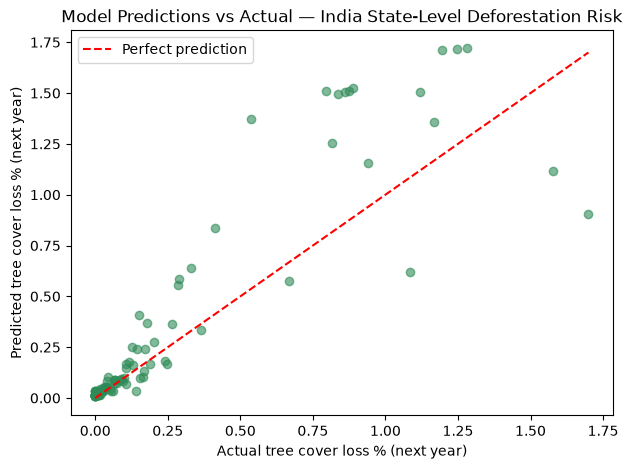

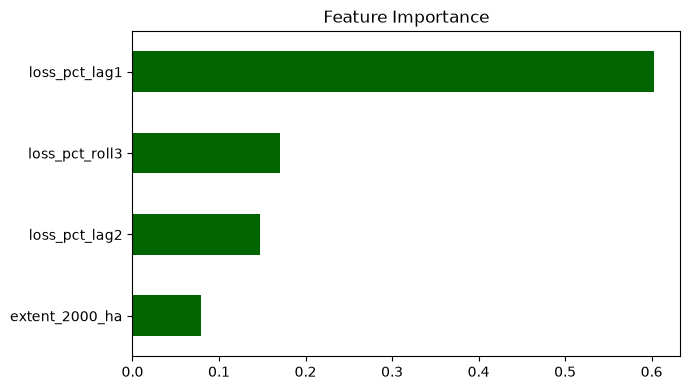

Model saved.


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import pandas as pd
import joblib

feature_cols = ['loss_pct_lag1', 'loss_pct_lag2', 'loss_pct_roll3', 'extent_2000_ha']
X = model_df[feature_cols]
y = model_df['target_loss_pct_next_year']


train_mask = model_df['year'] <= 2016
test_mask = model_df['year'] > 2016

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]

model = RandomForestRegressor(n_estimators=300, max_depth=5, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Naive baseline: "predict last year's value" — proves the model adds value
baseline_mae = mean_absolute_error(y_test, X_test['loss_pct_lag1'])

print(f'Model MAE: {mae:.3f}  |  R²: {r2:.3f}')
print(f'Naive baseline MAE: {baseline_mae:.3f}')
print(f'Improvement over baseline: {(1 - mae/baseline_mae)*100:.1f}%')

#  Actual vs Predicted
plt.figure(figsize=(7,5))
plt.scatter(y_test, y_pred, alpha=0.6, color='seagreen')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Perfect prediction')
plt.xlabel('Actual tree cover loss % (next year)')
plt.ylabel('Predicted tree cover loss % (next year)')
plt.title('Model Predictions vs Actual — India State-Level Deforestation Risk')
plt.legend()
plt.savefig('../models/actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

#  Feature importance
importances = pd.Series(model.feature_importances_, index=feature_cols).sort_values()
plt.figure(figsize=(7,4))
importances.plot(kind='barh', color='darkgreen')
plt.title('Feature Importance')
plt.tight_layout()
plt.savefig('../models/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

joblib.dump(model, '../models/risk_model.pkl')
print('Model saved.')